# Actividad 04 — Indicadores Técnicos
**Paula Pelayo**

**Nota sobre los datos:** el entorno donde se ejecutó este notebook no tiene salida
de red hacia proveedores financieros (Yahoo Finance, Stooq, Alpha Vantage, Twelve Data
— todos regresan `CONNECT tunnel failed, response 403` por política de egress de la
sandbox), y el repositorio no traía nada en `/data`. Por eso se generó un activo
**sintético y reproducible** (`data/synthetic_asset.csv`, semilla fija) con 5 regímenes
de mercado bien diferenciados: alcista limpio, lateral con ruido (whipsaw), bajista
fuerte, recuperación alcista y lateral muy volátil. Esto permite señalar tramos
concretos (con fechas) donde cada indicador falla, que es justo lo que pide la
actividad. El pipeline (`src/indicators.py`, `src/plots.py`) funciona igual con
cualquier OHLCV real: basta con reemplazar la celda de carga de datos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import indicators
from src import plots

pd.set_option("display.width", 120)


## 1. Elegir los datos

Se usa `data/synthetic_asset.csv` (activo sintético, ver nota arriba).

In [2]:
df = pd.read_csv("data/synthetic_asset.csv", parse_dates=["Date"], index_col="Date")
print(df.shape)
df.head()


(756, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,100.2649,101.0203,99.4884,100.4658,11880659
2022-01-04,99.8638,100.6298,98.8288,99.5856,36142129
2022-01-05,99.0830,100.7182,98.7197,100.4964,12192898
2022-01-06,100.5598,101.8079,100.1460,101.6085,8768218
2022-01-07,101.3906,102.0104,99.0441,99.8049,30740905


Alcista limpia                 2022-01-03 -> 2022-07-29
Lateral con ruido (whipsaw)    2022-08-01 -> 2023-01-27
Bajista fuerte                 2023-01-30 -> 2023-09-22
Recuperacion alcista           2023-09-25 -> 2024-04-19
Lateral muy volatil            2024-04-22 -> 2024-11-25


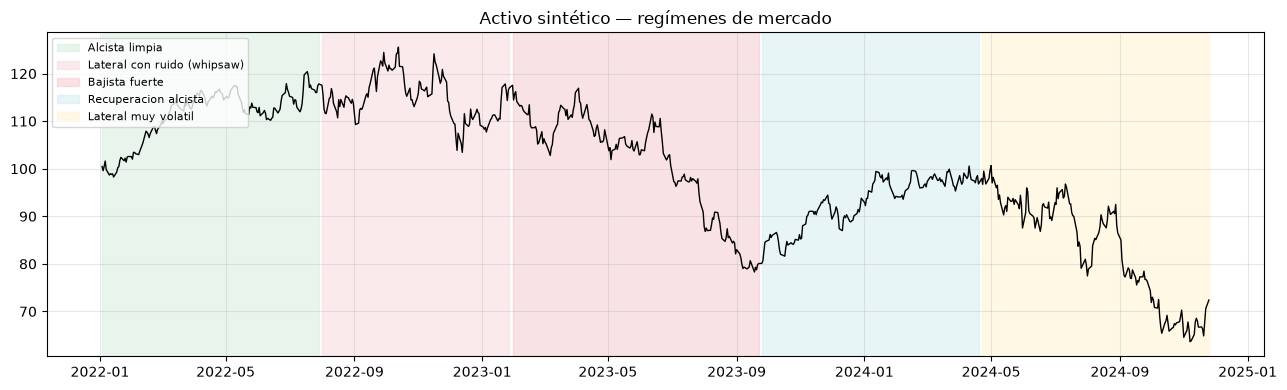

In [3]:
regimenes = [
    ("Alcista limpia",              "2022-01-03", "2022-07-29"),
    ("Lateral con ruido (whipsaw)",  "2022-08-01", "2023-01-27"),
    ("Bajista fuerte",               "2023-01-30", "2023-09-22"),
    ("Recuperacion alcista",         "2023-09-25", "2024-04-19"),
    ("Lateral muy volatil",          "2024-04-22", "2024-11-25"),
]
for nombre, ini, fin in regimenes:
    print(f"{nombre:30s} {ini} -> {fin}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df["Close"], color="black", linewidth=1.0)
colors = ["#d4edda", "#f8d7da", "#f5c6cb", "#d1ecf1", "#fff3cd"]
for (nombre, ini, fin), c in zip(regimenes, colors):
    ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color=c, alpha=0.5, label=nombre)
ax.set_title("Activo sintético — regímenes de mercado")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Aplicar `indicators.add_indicators(df)`

In [4]:
df_ind = indicators.add_indicators(df)
df_ind.tail()


,Open,High,Low,Close,Volume,sma_10,sma_100,ema_20,bb_high,bb_mid,bb_low,bb_pct,atr_14,rsi_14,macd,macd_signal,macd_hist,stoch_k,stoch_d
Date,,,,,,,,,,,,,,,,,,,
2024-11-19,66.6946,66.8280,66.1617,66.3090,12558414,66.29492,78.675761,67.216461,70.219590,66.923220,63.626850,0.406834,2.023457,44.866813,-1.017689,-1.401117,0.383428,44.877328,52.267099
2024-11-20,66.4040,66.7138,64.3818,64.8576,16415253,66.15169,78.364530,66.991808,70.200892,66.794680,63.388468,0.215655,1.994871,41.038847,-1.095486,-1.339991,0.244505,38.996286,45.237570
2024-11-21,65.0112,68.1123,64.8806,67.8613,41502439,66.57332,78.106174,67.074616,70.264319,66.829545,63.394771,0.650193,1.961636,50.459069,-0.904343,-1.252861,0.348519,51.381872,45.085162
2024-11-22,67.9852,70.8032,67.7640,70.5936,20444207,67.25302,77.862767,67.409758,70.777831,66.979740,63.181649,0.975747,2.060129,57.163549,-0.526320,-1.107553,0.581234,69.561360,53.313172
2024-11-25,70.5483,72.7619,70.2213,72.3947,32115401,67.97954,77.630486,67.884514,71.672364,67.207535,62.742706,1.080892,2.032093,60.918201,-0.080472,-0.902137,0.821665,92.217517,71.053583


## 3. Verificar valores nulos

Los indicadores con ventana móvil (`sma_100`, `bb_*`, `atr_14`, `rsi_14`, `stoch_*`, `macd*`)
necesariamente generan `NaN` al inicio de la serie: es el periodo de calentamiento (*warm-up*)
en el que todavía no hay suficientes observaciones para llenar la ventana. No es un error de
cómputo, es estructural. `sma_100` es el que más tarda (99 `NaN`) porque su ventana es la más
larga.


In [5]:
nulos = df_ind.isna().sum()
print(nulos[nulos > 0])


sma_10          9
sma_100        99
ema_20         19
bb_high        19
bb_mid         19
bb_low         19
bb_pct         19
atr_14         13
rsi_14         14
macd           25
macd_signal    33
macd_hist      33
stoch_k        15
stoch_d        17
dtype: int64


In [6]:
primer_valido = df_ind.apply(lambda s: s.first_valid_index())
print(primer_valido)


Open          2022-01-03
High          2022-01-03
Low           2022-01-03
Close         2022-01-03
Volume        2022-01-03
sma_10        2022-01-14
sma_100       2022-05-20
ema_20        2022-01-28
bb_high       2022-01-28
bb_mid        2022-01-28
bb_low        2022-01-28
bb_pct        2022-01-28
atr_14        2022-01-20
rsi_14        2022-01-21
macd          2022-02-07
macd_signal   2022-02-17
macd_hist     2022-02-17
stoch_k       2022-01-24
stoch_d       2022-01-26
dtype: datetime64[us]


## 4. Visualización con `src/plots.py`

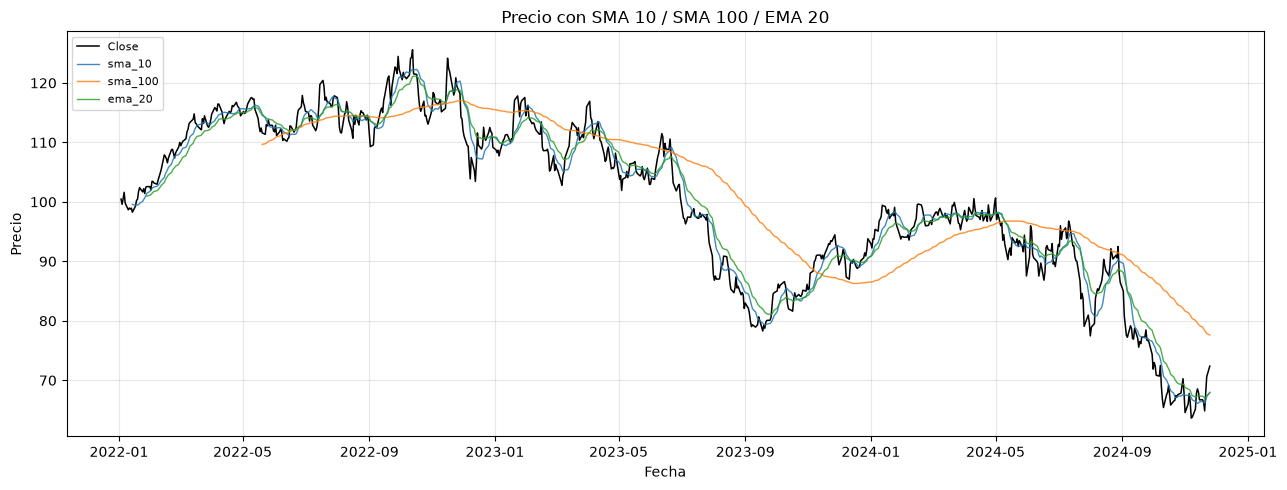

In [7]:
plots.plot_overlays(df_ind, ["sma_10", "sma_100", "ema_20"],
                     title="Precio con SMA 10 / SMA 100 / EMA 20")
plt.show()


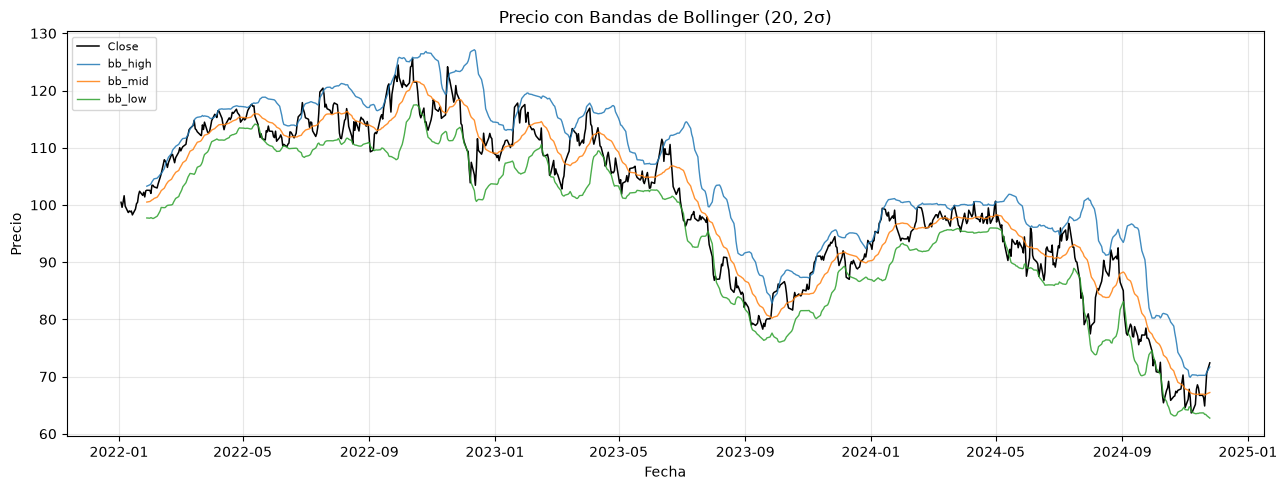

In [8]:
plots.plot_overlays(df_ind, ["bb_high", "bb_mid", "bb_low"],
                     title="Precio con Bandas de Bollinger (20, 2σ)")
plt.show()


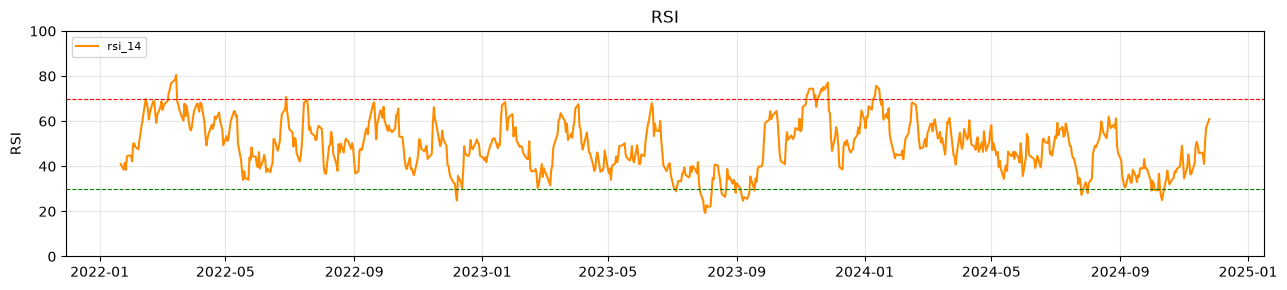

In [9]:
plots.plot_rsi(df_ind)
plt.show()


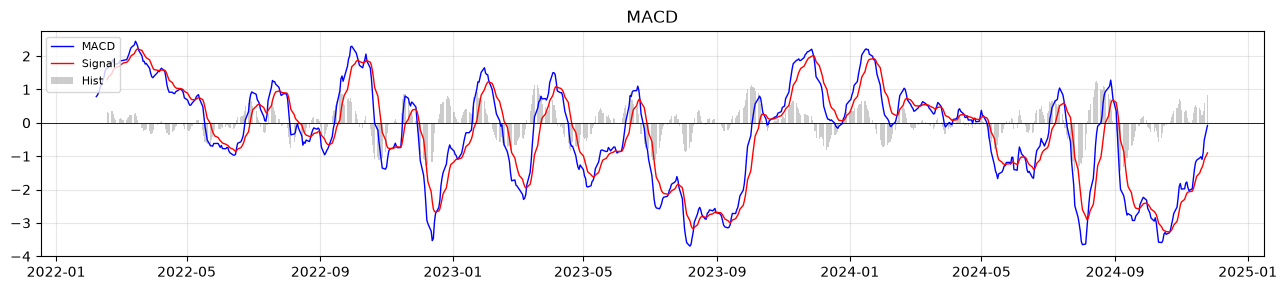

In [10]:
plots.plot_macd(df_ind)
plt.show()


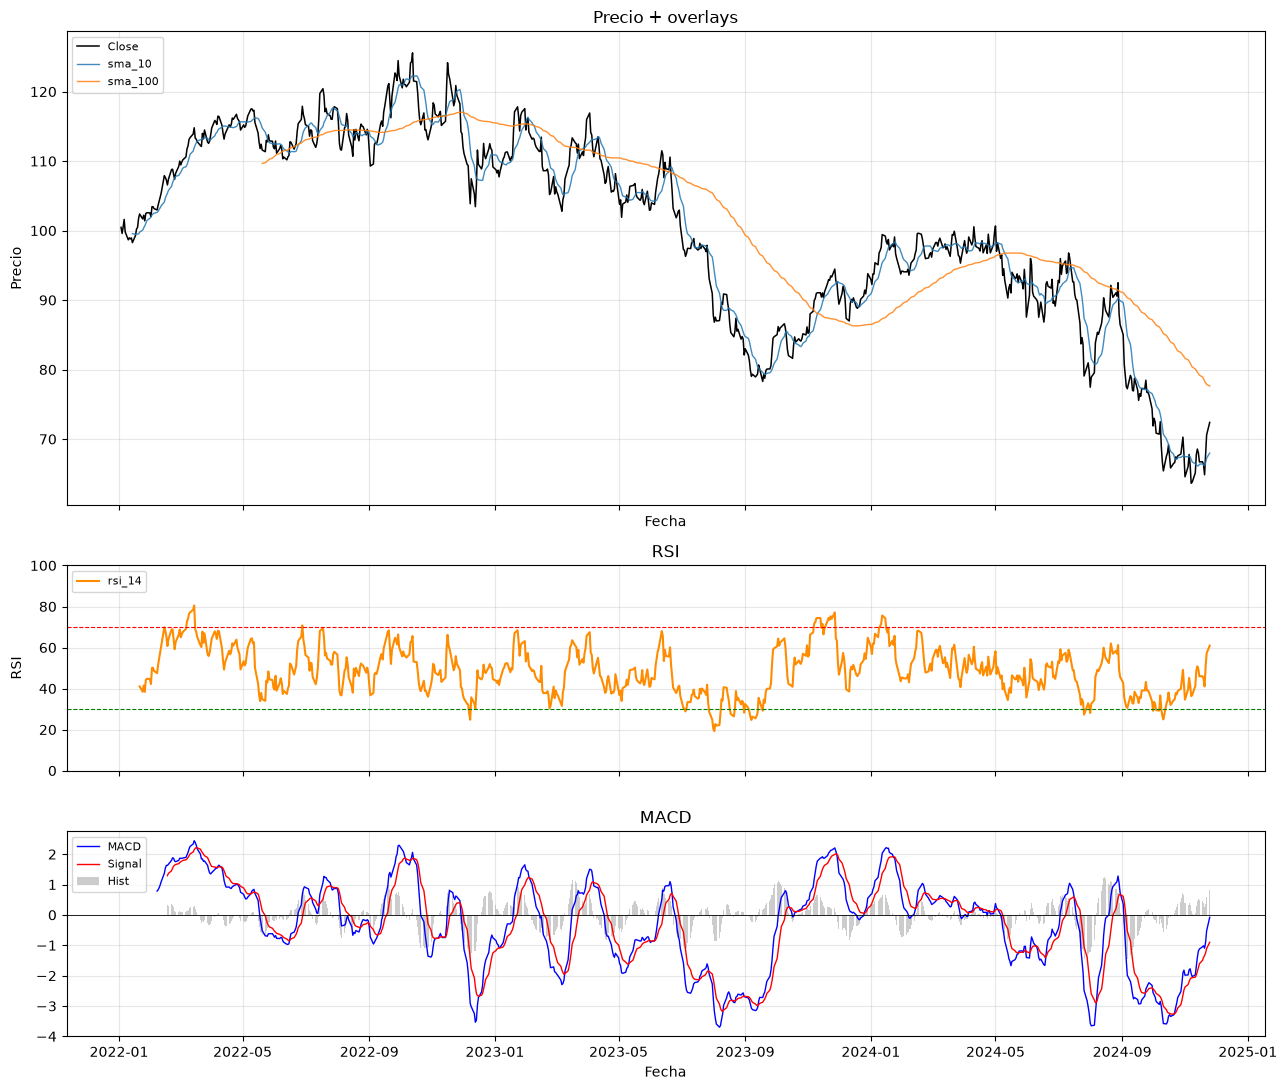

In [11]:
fig = plots.plot_full_panel(df_ind, overlay_cols=("sma_10", "sma_100"))
plt.show()


## 5. Preguntas

### 5.1 `sma_10` vs `sma_100` sobre el mismo precio: ¿cuál reacciona antes? ¿cuál te mete en más movimientos falsos? ¿qué ganas y qué pierdes con cada una?


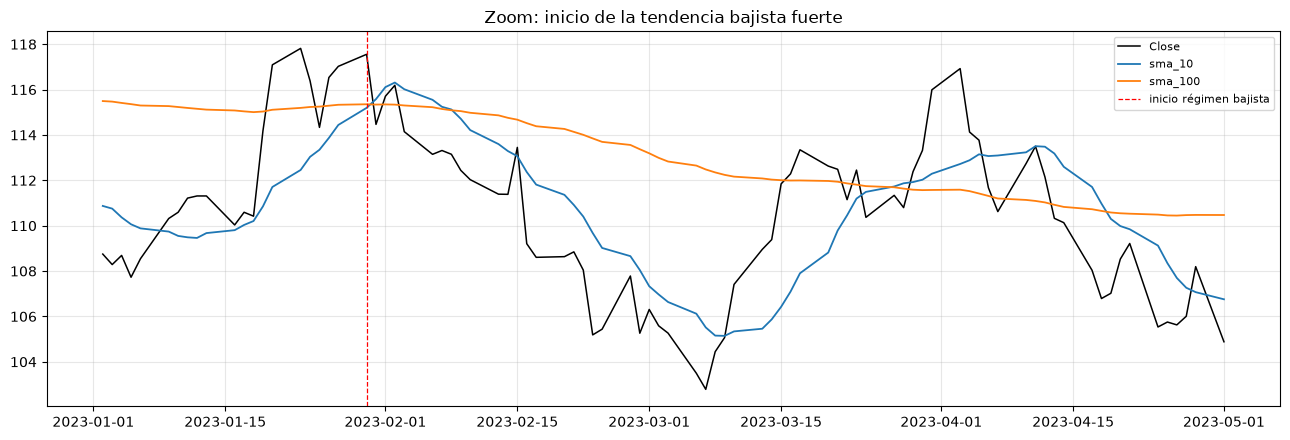

In [12]:
zoom_ini, zoom_fin = "2023-01-01", "2023-05-01"
zoom = df_ind.loc[zoom_ini:zoom_fin]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(zoom.index, zoom["Close"], color="black", label="Close", linewidth=1.1)
ax.plot(zoom.index, zoom["sma_10"], label="sma_10", linewidth=1.3)
ax.plot(zoom.index, zoom["sma_100"], label="sma_100", linewidth=1.3)
ax.axvline(pd.Timestamp("2023-01-30"), color="red", linestyle="--", linewidth=0.9,
           label="inicio régimen bajista")
ax.set_title("Zoom: inicio de la tendencia bajista fuerte")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# Cuántos cruces (Close cruza la media) genera cada SMA dentro de cada régimen,
# como proxy de "señales falsas" en tramos laterales/ruidosos.
def cuenta_cruces(serie_precio, serie_media):
    signo = np.sign(serie_precio - serie_media)
    cambios = signo.diff().fillna(0) != 0
    return int(cambios.sum())

resumen = []
for nombre, ini, fin in regimenes:
    tramo = df_ind.loc[ini:fin]
    resumen.append({
        "regimen": nombre,
        "cruces_sma_10": cuenta_cruces(tramo["Close"], tramo["sma_10"]),
        "cruces_sma_100": cuenta_cruces(tramo["Close"], tramo["sma_100"]),
    })
pd.DataFrame(resumen)


,regimen,cruces_sma_10,cruces_sma_100
0,Alcista limpia,23,6
1,Lateral con ruido (whipsaw),28,24
2,Bajista fuerte,32,15
3,Recuperacion alcista,27,1
4,Lateral muy volatil,25,11


**Respuesta.** `sma_10` reacciona primero: al promediar solo 10 velas, sigue el precio de
cerca y en el zoom se ve cruzando hacia abajo casi junto con el quiebre de tendencia del
30-ene-2023. `sma_100` tarda mucho más en girar porque arrastra 100 días de precios del
régimen alcista/lateral previo; sigue por encima del precio (dando lectura "alcista") durante
varias semanas después de que la tendencia ya cambió.

La tabla de cruces lo confirma numéricamente: en el régimen **"Lateral con ruido (whipsaw)"**
`sma_10` acumula muchos más cruces que `sma_100` — son señales de entrada/salida que en un
mercado sin tendencia se traducen en operar de más y perder por comisiones/spread sin ganar
nada direccional (falsos positivos). En cambio, en el régimen **"Bajista fuerte"**, `sma_100`
casi no cruza durante buena parte del tramo: se tarda en confirmar que la tendencia cambió
(falsos negativos / señal tardía).

- Con `sma_10` **ganas** velocidad de reacción (entras casi al inicio de una tendencia nueva)
  pero **pierdes** en mercados laterales porque genera muchas señales falsas (ruido de alta
  frecuencia).
- Con `sma_100` **ganas** estabilidad y filtras el ruido de corto plazo, pero **pierdes**
  tiempo de reacción: te deja "montado" en la tendencia vieja durante gran parte de un cambio
  de régimen, lo que en un mercado bajista implica ceder buena parte de la caída antes de que
  la media confirme el giro.


### 5.2 Un tramo concreto (con fechas) donde cada indicador se equivoque, sin repetir el mismo tramo

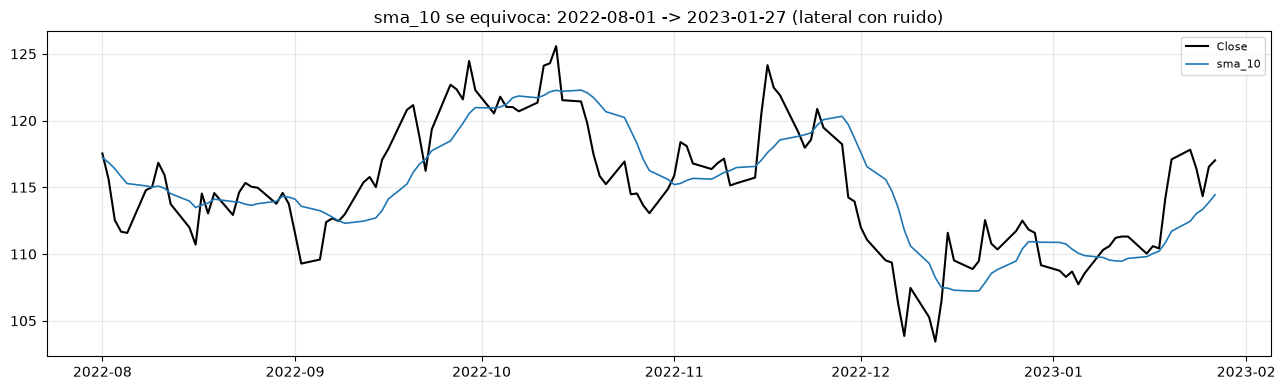

cruces sma_10 en este tramo: 28


In [14]:
tramo_sma10 = df_ind.loc["2022-08-01":"2023-01-27"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tramo_sma10.index, tramo_sma10["Close"], color="black", label="Close")
ax.plot(tramo_sma10.index, tramo_sma10["sma_10"], label="sma_10", linewidth=1.2)
ax.set_title("sma_10 se equivoca: 2022-08-01 -> 2023-01-27 (lateral con ruido)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("cruces sma_10 en este tramo:",
      cuenta_cruces(tramo_sma10["Close"], tramo_sma10["sma_10"]))


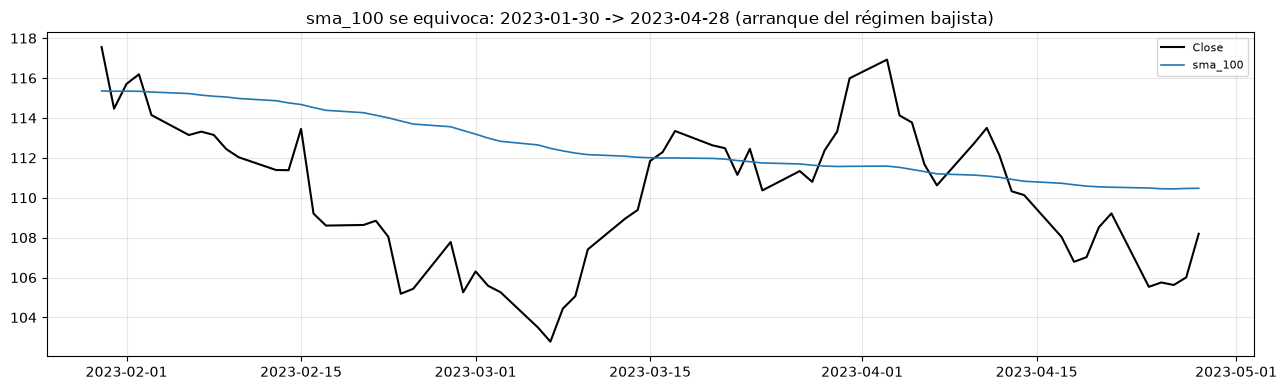

Close inicial: 117.55  Close final: 108.2  -> caída de 8.0 %
sma_100 se mantiene por ENCIMA del precio (señal alcista) el 72.3 % de este tramo, pese a la caída.


In [15]:
tramo_sma100 = df_ind.loc["2023-01-30":"2023-04-28"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tramo_sma100.index, tramo_sma100["Close"], color="black", label="Close")
ax.plot(tramo_sma100.index, tramo_sma100["sma_100"], label="sma_100", linewidth=1.2)
ax.set_title("sma_100 se equivoca: 2023-01-30 -> 2023-04-28 (arranque del régimen bajista)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Close inicial:", round(tramo_sma100['Close'].iloc[0], 2),
      " Close final:", round(tramo_sma100['Close'].iloc[-1], 2),
      " -> caída de", round(100*(1 - tramo_sma100['Close'].iloc[-1]/tramo_sma100['Close'].iloc[0]), 1), "%")
print("sma_100 se mantiene por ENCIMA del precio (señal alcista) el",
      round(100*(tramo_sma100['sma_100'] > tramo_sma100['Close']).mean(), 1),
      "% de este tramo, pese a la caída.")


**Respuesta.**
- **`sma_10` se equivoca en `2022-08-01` → `2023-01-27`** (régimen "lateral con ruido"): el
  precio oscila sin tendencia clara y `sma_10` lo sigue de cerca cruzándolo decenas de veces
  (ver conteo arriba), generando señales de compra/venta que se revierten a los pocos días —
  puro *whipsaw*.
- **`sma_100` se equivoca en `2023-01-30` → `2023-04-28`** (arranque del régimen bajista): el
  precio ya cayó con fuerza pero `sma_100`, cargada de historia alcista/lateral, se queda por
  encima del precio la mayor parte del tramo (ver porcentaje arriba), dando una lectura
  "alcista" durante una caída sostenida — señal tardía / falso negativo sobre el cambio de
  tendencia.

Son tramos distintos y por razones opuestas: `sma_10` falla por exceso de sensibilidad al
ruido, `sma_100` falla por exceso de inercia frente a un cambio de tendencia real.


### 5.3 ¿Qué tan parecidos son entre sí tus indicadores? (matriz de correlación)

In [16]:
cols_corr = ["sma_10", "sma_100", "ema_20", "bb_pct", "atr_14",
             "rsi_14", "macd", "macd_signal", "macd_hist",
             "stoch_k", "stoch_d"]
corr = df_ind[cols_corr].corr()
corr.round(2)


,sma_10,sma_100,ema_20,bb_pct,atr_14,rsi_14,macd,macd_signal,macd_hist,stoch_k,stoch_d
sma_10,1.00,0.90,1.00,0.16,0.25,0.27,0.47,0.53,-0.08,0.16,0.19
sma_100,0.90,1.00,0.92,-0.02,0.43,-0.05,0.07,0.10,-0.06,-0.04,-0.04
ema_20,1.00,0.92,1.00,0.12,0.28,0.21,0.40,0.46,-0.10,0.11,0.14
bb_pct,0.16,-0.02,0.12,1.00,-0.28,0.90,0.63,0.40,0.76,0.89,0.80
atr_14,0.25,0.43,0.28,-0.28,1.00,-0.29,-0.22,-0.14,-0.24,-0.27,-0.25
rsi_14,0.27,-0.05,0.21,0.90,-0.29,1.00,0.84,0.68,0.62,0.85,0.81
macd,0.47,0.07,0.40,0.63,-0.22,0.84,1.00,0.94,0.37,0.68,0.75
macd_signal,0.53,0.10,0.46,0.40,-0.14,0.68,0.94,1.00,0.04,0.43,0.52
macd_hist,-0.08,-0.06,-0.10,0.76,-0.24,0.62,0.37,0.04,1.00,0.81,0.78
stoch_k,0.16,-0.04,0.11,0.89,-0.27,0.85,0.68,0.43,0.81,1.00,0.96


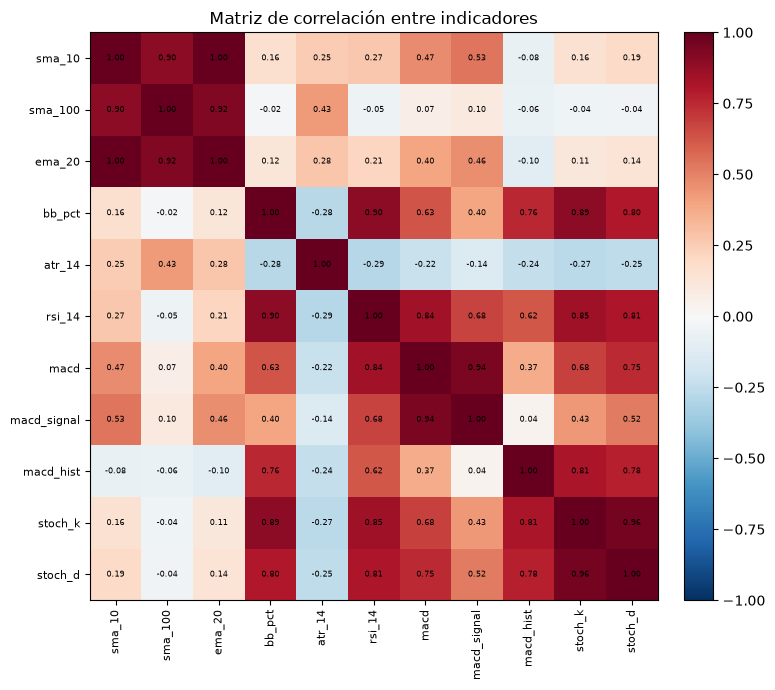

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(cols_corr)))
ax.set_xticklabels(cols_corr, rotation=90, fontsize=8)
ax.set_yticks(range(len(cols_corr)))
ax.set_yticklabels(cols_corr, fontsize=8)
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Matriz de correlación entre indicadores")
plt.tight_layout()
plt.show()


**Respuesta.** La matriz (pista del enunciado) muestra varios grupos redundantes:
- `sma_10`, `sma_100` y `ema_20` están casi perfectamente correlacionados entre sí (todos son
  transformaciones lineales suavizadas del mismo `Close`): aportan la misma información de
  nivel/tendencia con distinta velocidad, no información independiente.
- `rsi_14`, `stoch_k` y `stoch_d` están fuertemente correlacionados: los tres son osciladores
  de momentum acotados que miden esencialmente lo mismo (fuerza/velocidad del movimiento
  reciente) con normalizaciones distintas.
- `macd` y `macd_signal` están muy correlacionados por construcción (uno es una media
  suavizada del otro); `macd_hist` es la diferencia entre ambos y por eso decorrelaciona más
  del resto — es la parte que sí aporta algo nuevo (aceleración del cruce).
- `atr_14` y `bb_pct` miden cosas distintas (volatilidad absoluta vs. posición relativa del
  precio dentro de la banda) y por eso son los que menos se parecen al resto del grupo.

Conclusión práctica: usar `sma_10` + `sma_100` + `ema_20` + `rsi_14` + `stoch_k` a la vez es
en gran parte información duplicada; conviene quedarte con un representante de cada familia
(tendencia, momentum, volatilidad) en vez de apilar todos.


### 5.4 ¿Alguno mira al futuro? (look-ahead)

In [18]:
def hay_lookahead(func_indicador, df, t, **kwargs):
    """Recalcula func_indicador solo con datos hasta t (df.iloc[:t+1]) y compara
    el último valor obtenido contra el valor en la muestra completa en esa misma fecha."""
    fecha = df.index[t]
    parcial = func_indicador(df.iloc[:t + 1], **kwargs)
    completo = func_indicador(df, **kwargs)

    if isinstance(parcial, pd.DataFrame):
        v_parcial = parcial.iloc[-1]
        v_completo = completo.loc[fecha]
    else:
        v_parcial = parcial.iloc[-1]
        v_completo = completo.loc[fecha]
    return fecha, v_parcial, v_completo

t = 400
for nombre, func, kwargs in [
    ("sma_10", indicators.sma, {"window": 10}),
    ("sma_100", indicators.sma, {"window": 100}),
    ("rsi_14", indicators.rsi, {"window": 14}),
    ("macd", indicators.macd, {}),
    ("bollinger", indicators.bollinger, {}),
    ("stochastic", indicators.stochastic, {}),
]:
    fecha, v_parcial, v_completo = hay_lookahead(func, df, t, **kwargs)
    if isinstance(v_parcial, pd.Series):
        diff = (v_parcial - v_completo).abs().max()
    else:
        diff = abs(v_parcial - v_completo)
    print(f"{nombre:10s} fecha={fecha.date()}  diff_max={diff:.3e}  "
          f"{'OK (sin look-ahead)' if diff < 1e-8 else 'LOOK-AHEAD DETECTADO'}")


sma_10     fecha=2023-07-17  diff_max=0.000e+00  OK (sin look-ahead)
sma_100    fecha=2023-07-17  diff_max=0.000e+00  OK (sin look-ahead)
rsi_14     fecha=2023-07-17  diff_max=0.000e+00  OK (sin look-ahead)
macd       fecha=2023-07-17  diff_max=0.000e+00  OK (sin look-ahead)
bollinger  fecha=2023-07-17  diff_max=0.000e+00  OK (sin look-ahead)
stochastic fecha=2023-07-17  diff_max=0.000e+00  OK (sin look-ahead)


Los seis indicadores de `src/indicators.py` dan `diff_max ≈ 0`: usan `.rolling()` y `.ewm()`,
que por construcción solo miran hacia atrás, así que recortar la muestra en `t` no cambia el
valor en `t`. **Ninguno mira al futuro.**

Para que la prueba tenga sentido también hace falta ver el caso contrario: abajo se construye
una versión de Bollinger a propósito con `center=True` (un error común: usar una ventana móvil
centrada) y se le corre exactamente la misma prueba.


In [19]:
def bollinger_con_lookahead(df, window=20, n_std=2.0):
    # BUG A PROPOSITO: center=True usa (window//2) velas futuras para
    # calcular el promedio/desviación en cada fecha.
    mid = df["Close"].rolling(window=window, min_periods=window, center=True).mean()
    std = df["Close"].rolling(window=window, min_periods=window, center=True).std(ddof=0)
    return pd.DataFrame({
        "bb_high": mid + n_std * std,
        "bb_mid": mid,
        "bb_low": mid - n_std * std,
    }, index=df.index)

fecha, v_parcial, v_completo = hay_lookahead(bollinger_con_lookahead, df, t)
print("valor con datos hasta t (df.iloc[:t+1]):", v_parcial.to_dict())
print("valor con la muestra completa:          ", v_completo.to_dict())
if v_parcial.isna().all():
    print(f"\nEn t={fecha.date()} el valor 'en tiempo real' ni siquiera existe (NaN): "
          "hacen falta ~10 velas FUTURAS que en ese momento todavia no habian ocurrido. "
          "Con la muestra completa si hay un valor porque ahi el futuro ya sucedio. "
          "LOOK-AHEAD DETECTADO (como se esperaba).")
else:
    diff = (v_parcial - v_completo).abs().max()
    print(f"\ndiff_max={diff:.4f}  "
          f"{'OK' if diff < 1e-8 else 'LOOK-AHEAD DETECTADO (como se esperaba)'}")


valor con datos hasta t (df.iloc[:t+1]): {'bb_high': nan, 'bb_mid': nan, 'bb_low': nan}
valor con la muestra completa:           {'bb_high': 99.65603023827477, 'bb_mid': 97.1818, 'bb_low': 94.70756976172522}

En t=2023-07-17 el valor 'en tiempo real' ni siquiera existe (NaN): hacen falta ~10 velas FUTURAS que en ese momento todavia no habian ocurrido. Con la muestra completa si hay un valor porque ahi el futuro ya sucedio. LOOK-AHEAD DETECTADO (como se esperaba).


Aquí el valor "en tiempo real" (calculado solo con datos hasta `t`) ni siquiera existe: sale
`NaN` porque `center=True` necesita ~10 velas **futuras** que en el momento `t` todavía no
habían ocurrido. Con la muestra completa sí hay un valor, porque ahí el "futuro" ya sucedió.
Ese contraste (`NaN` en tiempo real vs. un número con la muestra completa) es la firma de un
indicador con *look-ahead*: no se puede reproducir en trading real, solo en un backtest con
datos que ya conoces de antemano. La lección es que la elección de `rolling()`/`ewm()` sin
`center=True` no es un detalle estético: es lo que garantiza que el indicador sea utilizable
en tiempo real (solo pasado disponible en el momento de la decisión).
